# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muzammilsharf/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [8]:
# importing data
import pandas as pd
import json
import lightgbm as lgb
from sklearn.model_selection import GroupShuffleSplit

model_df_encoded = pd.read_parquet('data/flyrank_snapshots.parquet')
with open('data/flyrank_meta.json') as f:
    features = json.load(f)["features"]

print(model_df_encoded.shape)

(357671, 47)


In [9]:
spike_months = ["2026-03", "2026-04"]
train_full = model_df_encoded[~model_df_encoded["report_date"].dt.to_period("M").astype(str).isin(spike_months)]

final_model = lgb.LGBMClassifier(n_estimators=300, max_depth=6, num_leaves=31,
                                   learning_rate=0.05, is_unbalance=True, random_state=42, verbosity=-1)
final_model.fit(train_full[features], train_full["is_declining_label"])

queue = model_df_encoded.copy()
queue["risk_score"] = final_model.predict_proba(queue[features])[:, 1]

def assign_reason_code(row, position_baselines):
    expected_ctr = position_baselines.get(round(row["avg_position_90d"]), position_baselines.get("default", 1.0))
    if row["ctr_90d"] < expected_ctr * 0.3 and row["avg_position_90d"] <= 10:
        return "SEVERE_CTR_DEFICIT", "Snippet/title fix"
    if row["impressions_90d"] < 5000 and 11 <= row["avg_position_90d"] <= 20:
        return "PAGE_ONE_OPPORTUNITY", "Depth expansion + internal links"
    if pd.notna(row.get("engagement_sec_90d")) and row["engagement_sec_90d"] < 30 and row["clicks_90d"] > 50:
        return "LOW_ENGAGEMENT", "Content structure fix"
    return "GENERAL_DECLINE_RISK", "Freshness review"

position_baselines = queue.groupby(queue["avg_position_90d"].round())["ctr_90d"].median().to_dict()
position_baselines["default"] = queue["ctr_90d"].median()

queue[["reason_code", "suggested_action"]] = queue.apply(
    lambda r: pd.Series(assign_reason_code(r, position_baselines)), axis=1
)

ranked_queue = queue.sort_values("risk_score", ascending=False)
print(ranked_queue["reason_code"].value_counts())
print(ranked_queue[["content_hash_id", "client_hash_id", "risk_score", "reason_code", "suggested_action"]].head(10).to_string(index=False))

reason_code
GENERAL_DECLINE_RISK    261679
PAGE_ONE_OPPORTUNITY     51980
SEVERE_CTR_DEFICIT       40635
LOW_ENGAGEMENT            3377
Name: count, dtype: int64
         content_hash_id          client_hash_id  risk_score          reason_code suggested_action
content_88180b9798e157df client_9958f0a7ae1df715    0.986815 GENERAL_DECLINE_RISK Freshness review
content_ad1f668b6c7badc2 client_9958f0a7ae1df715    0.985761 GENERAL_DECLINE_RISK Freshness review
content_cd4f8d41fa9457e4 client_9958f0a7ae1df715    0.984959 GENERAL_DECLINE_RISK Freshness review
content_c6138fac1cb3c601 client_9958f0a7ae1df715    0.984287 GENERAL_DECLINE_RISK Freshness review
content_886b8b91dcc085c6 client_9958f0a7ae1df715    0.983443 GENERAL_DECLINE_RISK Freshness review
content_803e6bf13d4af2d0 client_400c21c81c8b46ef    0.983177 GENERAL_DECLINE_RISK Freshness review
content_c2e6f3231e25d072 client_9958f0a7ae1df715    0.982861 GENERAL_DECLINE_RISK Freshness review
content_336125a54dcd49e5 client_9958f0a7ae1df7

Each flagged page gets a risk score (0-1, model output) and a reason code explaining *why*, following the same population→evidence→condition→action structure used for the Week-4 baseline. Reason codes map to the four content-decay patterns identified in the lecture: a snippet/CTR problem (strong position, weak clicks), a page-one opportunity (page-2 position, real search volume), a low-engagement problem (clicks arrive, visitors don't stay), or a general freshness review when no single signal dominates. This gives a reviewer a starting hypothesis, not a diagnosis, they still need to check the actual page.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use:** a weekly-refreshed prioritization queue for a content team with limited review capacity, ranking which pages to look at first, not an automated content-editing system.

**Where it stops being valid:**
- **Anomalous periods.** The model excludes March-April 2026 from training and evaluation, a period with a genuine, widespread decline spike whose cause isn't established. Scores generated during a similar future event should be treated as unreliable until re-validated.
- **The excluded client.** `client_08a6a72ff48e62c0` was removed from all modeling due to a suspected data-quality issue (near-duplicate aggregate signatures across hundreds of distinct pages). This tool should not be used for that client's content without separately investigating the underlying data.
- **GA4-sparse pages.** Only ~17% of rows have GA4 tracking coverage in their feature window. Engagement-based reason codes (`LOW_ENGAGEMENT`) are only meaningful for pages where that data exists, absence of the flag doesn't mean engagement is fine, it may mean it's untracked.
- **Small-client-count variance.** With only 36 total clients in this warehouse slice, Precision@50 varied from 58% to 96% across validation runs (mean 78.8%). A given week's queue should be expected to fall somewhere in that range, not hit a fixed number every time.
- **Not causal.** A high risk score means "this page resembles others that later declined," not "this page will decline" or "not fixing it will cause loss." No experiment has been run to confirm that acting on a flagged page changes its outcome.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Before acting on any flagged page, a human must check:**
- Is this a real page decline, or a look-alike? Rule out consolidation (a sibling page absorbing traffic), seasonality, and SERP feature changes before treating the flag as real.
- Does the reason code's underlying signal actually hold up on inspection (e.g. for `SEVERE_CTR_DEFICIT`, is it really a zero-click SERP feature at position 1-3, which the baseline audit already showed is a common false positive)?
- Is the page currently in a "cooldown" period after a recent edit? A page that was just updated shouldn't be flagged for another update.

**What should NEVER be automated:**
- Auto-publishing content edits, titles, or meta descriptions based on the risk score alone.
- Auto-deleting or de-indexing pages flagged as declining.
- Treating the risk score as a public-facing claim ("this page is failing") without human verification, it's an internal prioritization signal only.
- Acting on scores generated during an unvalidated anomalous period (see Section 2) without separate review.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**Signs the recommendations have gone stale:**
- The overall decline-label rate in fresh data drifts far outside the observed historical range (roughly 17-57% month to month); a sudden jump, like the March-April 2026 spike, is itself a trigger to pause automated scoring and investigate before trusting new recommendations.
- A new client's data shows the same near-duplicate-signature pattern found in the excluded client, flag and exclude before it contaminates a retrain.
- GA4 coverage crosses a meaningfully higher threshold (most clients' tracking only started in 2026); once coverage broadly improves, engagement-based reason codes should be re-evaluated since they were tuned on a mostly-sparse period.
- Precision@50 on a fresh holdout month falls persistently below the observed range (under ~55%) across multiple weeks, not just one noisy week, given the known seed-to-seed variance.

**Retrain cadence:** monthly, using the most recent full month once its future-30-day label window is available (roughly a 60-day lag from "live" to "labeled"), rebuilding from the same pipeline validated in w05/w06.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [10]:
import os
os.makedirs('../outputs', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

export_cols = ["content_hash_id", "client_hash_id", "risk_score", "reason_code", "suggested_action",
               "impressions_90d", "ctr_90d", "avg_position_90d"]
ranked_queue[export_cols].to_csv('../outputs/action_playbook_queue.csv', index=False)

metrics = {
    "model": "LightGBM",
    "precision_at_50_mean": 0.788,
    "precision_at_50_std": 0.122,
    "precision_at_50_range": [0.560, 0.940],
    "validation_seeds": [42, 7, 123, 2024, 99],
    "excluded_client": "client_08a6a72ff48e62c0",
    "excluded_periods": ["2026-03", "2026-04"],
    "total_features": len(features),
    "total_scored_pages": len(ranked_queue)
}
with open('../outputs/model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("Exported queue and metrics.")

Exported queue and metrics.


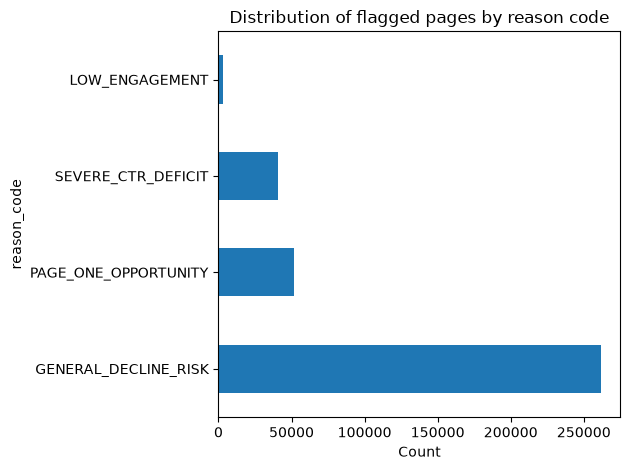

In [11]:
import matplotlib.pyplot as plt

ranked_queue["reason_code"].value_counts().plot(kind="barh")
plt.xlabel("Count")
plt.title("Distribution of flagged pages by reason code")
plt.tight_layout()
plt.savefig('../figures/reason_code_distribution.png', dpi=150)
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.